# Experiment 8 - Detailed HSV + Texture

**Pipeline preprocessing:** Baseline (resize) ditambah ekstraksi fitur histogram 1D warna HSV (16 bin H, 8 bin S, 8 bin V = 32 bin) dan statistik warna orde pertama (mean, std dev, skewness, kurtosis untuk H, S, V = 12 fitur) dikombinasikan dengan GLCM tekstur grayscale, tanpa menggunakan LBP.

## Setup

In [1]:
import sys
import os

if 'google.colab' in sys.modules:
    print("Berjalan di Google Colab. Menyiapkan environment...")
    from google.colab import drive
    drive.mount('/content/drive')
    
    REPO_DIR = '/content/cloud-classification'
    if not os.path.exists(REPO_DIR):
        !git clone https://github.com/Vuxyn/cloud-classification.git
    else:
        !git -C {REPO_DIR} pull
        
    %cd {REPO_DIR}/notebooks
    
    ZIP_PATH = '/content/drive/MyDrive/GCD-zip.zip'
    EXTRACT_DIR = '/content/GCD-zip'
    
    if os.path.exists(ZIP_PATH):
        if not os.path.exists(EXTRACT_DIR):
            print(f"Mengekstrak {ZIP_PATH} ke {EXTRACT_DIR}...")
            import zipfile
            with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
                zip_ref.extractall(EXTRACT_DIR)
            print("Ekstraksi selesai!")
        else:
            print(f"Dataset sudah diekstrak di {EXTRACT_DIR}")
    else:
        print(f"Peringatan: File zip {ZIP_PATH} tidak ditemukan di Google Drive Anda.")
        print("Pastikan nama file zip di Drive utama adalah 'GCD-zip.zip'.")

    # Cek apakah runtime menggunakan GPU
    import subprocess
    try:
        subprocess.check_output('nvidia-smi')
        print("GPU NVIDIA terdeteksi, menginstall cupy...")
        !pip install cupy-cuda12x python-dotenv gdown scipy
    except Exception:
        print("GPU tidak aktif. Menjalankan menggunakan CPU.")
        !pip install python-dotenv gdown scipy

In [2]:
import sys
sys.path.append('..')  # supaya src/ bisa diimport dari notebooks/

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.stats import skew, kurtosis
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from src.loader import get_dataset_root, load_dataset
from src.image_processing import *

EXPERIMENT_NAME = "experiment8"

CuPy tidak tersedia - fallback ke NumPy (CPU)


## Data Loading

In [3]:
DATASET_ROOT = get_dataset_root()
# Muat gambar warna asli (color=True) untuk fitur warna HSV detail
images, labels, filenames = load_dataset(DATASET_ROOT, target_size=(128, 128), color=True)
print(f"Dataset loaded: {len(images)} gambar warna, {len(set(labels))} kelas")

Environment: Lokal
DATASET_ROOT dari .env: D:\INFORMATICS\SEMESTER 4\IMAGE PROCESSING\Praktikum\Project\GCD



Loading cumulus:   0%|          | 0/775 [00:00<?, ?it/s]


Loading cumulus:  19%|█▉        | 146/775 [00:00<00:00, 1450.65it/s]


Loading cumulus:  38%|███▊      | 293/775 [00:00<00:00, 1461.73it/s]


Loading cumulus:  57%|█████▋    | 440/775 [00:00<00:00, 1465.18it/s]

...


Loading mixed:  50%|█████     | 305/607 [00:00<00:00, 966.48it/s] 


Loading mixed:  66%|██████▌   | 402/607 [00:00<00:00, 882.55it/s]


Loading mixed:  81%|████████  | 492/607 [00:00<00:00, 834.25it/s]


Loading mixed:  95%|█████████▌| 577/607 [00:00<00:00, 824.15it/s]

Dataset loaded: 19000 gambar, 7 kelas, ukuran=(128, 128)
Dataset loaded: 19000 gambar warna, 7 kelas


## Dataset Visualization & Distribution

In [ ]:
# Tampilkan contoh gambar untuk setiap kelas
unique_labels = sorted(list(set(labels)))
fig, axes = plt.subplots(1, len(unique_labels), figsize=(15, 3))
for i, label in enumerate(unique_labels):
    idx = np.where(labels == label)[0][0]
    img = images[idx]
    if len(img.shape) == 3:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img_rgb)
    else:
        axes[i].imshow(img, cmap='gray')
    axes[i].set_title(label, fontsize=10)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

# Tampilkan bar chart distribusi kelas
plt.figure(figsize=(10, 4))
label_counts = pd.Series(labels).value_counts().sort_index()
sns.barplot(x=label_counts.index, y=label_counts.values, palette='Blues_d')
plt.title('Distribusi Jumlah Data Per Kelas Awan')
plt.xlabel('Kelas Awan')
plt.ylabel('Jumlah Gambar')
for i, count in enumerate(label_counts.values):
    plt.text(i, count + 100, str(count), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

In [4]:
# ================================================================
# EDIT BAGIAN INI untuk mengubah pipeline preprocessing
# ================================================================
PIPELINE = []


def apply_pipeline(image: np.ndarray, pipeline: list) -> np.ndarray:
    for fn in pipeline:
        image = fn(image)
    return image

In [5]:
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor

def process_one(img):
    return apply_pipeline(img, PIPELINE)

if not PIPELINE:
    images_preprocessed_color = images.copy()
else:
    if USING_GPU:
        print("Menggunakan ThreadPoolExecutor (GPU aktif)...")
        with ThreadPoolExecutor(max_workers=4) as executor:
            images_preprocessed_color = list(tqdm(
                executor.map(process_one, images),
                total=len(images),
                desc="Preprocessing"
            ))
    else:
        print("Menggunakan Pemrosesan Sekuensial CPU...")
        images_preprocessed_color = [process_one(img) for img in tqdm(images, desc="Preprocessing")]
        
    images_preprocessed_color = np.array(images_preprocessed_color)

## Feature Extraction - Detailed Color HSV

In [6]:
h_hists, s_hists, v_hists, h_means, h_stds, h_skews, h_kurts, s_means, s_stds, s_skews, s_kurts, v_means, v_stds, v_skews, v_kurts = extract_hsv_features(images_preprocessed_color)

## Preprocessing for GLCM (Convert to Grayscale)

In [7]:
if images_preprocessed_color.ndim == 4:
    images_preprocessed = np.array([
        cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) for img in tqdm(images_preprocessed_color, desc="Converting to grayscale")
    ])
else:
    images_preprocessed = images_preprocessed_color


Converting to grayscale:   0%|          | 0/19000 [00:00<?, ?it/s]


Converting to grayscale:  31%|███▏      | 5965/19000 [00:00<00:00, 59642.38it/s]


Converting to grayscale:  64%|██████▍   | 12138/19000 [00:00<00:00, 60866.43it/s]


Converting to grayscale:  98%|█████████▊| 18531/19000 [00:00<00:00, 62260.18it/s]


Converting to grayscale: 100%|██████████| 19000/19000 [00:00<00:00, 61496.45it/s]

## Feature Extraction - GLCM Texture

In [8]:
def glcm(image, angle):
    if angle == 0:
        angles = [0]
    elif angle == 45:
        angles = [np.pi / 4]
    elif angle == 90:
        angles = [np.pi / 2]
    elif angle == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Sudut tidak valid. Gunakan 0, 45, 90, atau 135.")

    return graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)


def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]


def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]


def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]


def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]


def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]


def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]


def entropyGlcm(matriks):
    return entropy(matriks.ravel())


In [9]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 = [], [], [], []
ASM0, ASM45, ASM90, ASM135 = [], [], [], []
energy0, energy45, energy90, energy135 = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in tqdm(range(len(images_preprocessed)), desc="Extracting GLCM features"):
    g0 = glcm(images_preprocessed[i], 0)
    g45 = glcm(images_preprocessed[i], 45)
    g90 = glcm(images_preprocessed[i], 90)
    g135 = glcm(images_preprocessed[i], 135)
    
    Kontras0.append(contrast(g0))
    Kontras45.append(contrast(g45))
    Kontras90.append(contrast(g90))
    Kontras135.append(contrast(g135))
    
    dissimilarity0.append(dissimilarity(g0))
    dissimilarity45.append(dissimilarity(g45))
    dissimilarity90.append(dissimilarity(g90))
    dissimilarity135.append(dissimilarity(g135))
    
    homogenity0.append(homogenity(g0))
    homogenity45.append(homogenity(g45))
    homogenity90.append(homogenity(g90))
    homogenity135.append(homogenity(g135))
    
    entropy0.append(entropyGlcm(g0))
    entropy45.append(entropyGlcm(g45))
    entropy90.append(entropyGlcm(g90))
    entropy135.append(entropyGlcm(g135))
    
    ASM0.append(ASM(g0))
    ASM45.append(ASM(g45))
    ASM90.append(ASM(g90))
    ASM135.append(ASM(g135))
    
    energy0.append(energy(g0))
    energy45.append(energy(g45))
    energy90.append(energy(g90))
    energy135.append(energy(g135))
    
    correlation0.append(correlation(g0))
    correlation45.append(correlation(g45))
    correlation90.append(correlation(g90))
    correlation135.append(correlation(g135))


Extracting GLCM features:   0%|          | 0/19000 [00:00<?, ?it/s]


Extracting GLCM features:   0%|          | 5/19000 [00:00<06:21, 49.85it/s]


Extracting GLCM features:   0%|          | 14/19000 [00:00<04:26, 71.27it/s]


Extracting GLCM features:   0%|          | 24/19000 [00:00<03:51, 81.95it/s]


Extracting GLCM features:   0%|          | 35/19000 [00:00<03:27, 91.19it/s]

...


Extracting GLCM features: 100%|█████████▉| 18960/19000 [02:43<00:00, 111.95it/s]


Extracting GLCM features: 100%|█████████▉| 18972/19000 [02:43<00:00, 111.70it/s]


Extracting GLCM features: 100%|█████████▉| 18984/19000 [02:43<00:00, 111.11it/s]


Extracting GLCM features: 100%|█████████▉| 18997/19000 [02:43<00:00, 114.06it/s]


Extracting GLCM features: 100%|██████████| 19000/19000 [02:43<00:00, 115.86it/s]

In [10]:
dataTable = {
    'Filename': filenames,
    'Label': labels,
    # Fitur Tekstur GLCM
    'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
    'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
    'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
    'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
    'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
    'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
    'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
    # Statistik Warna HSV
    'HSV_H_Mean': h_means, 'HSV_H_Std': h_stds, 'HSV_H_Skew': h_skews, 'HSV_H_Kurt': h_kurts,
    'HSV_S_Mean': s_means, 'HSV_S_Std': s_stds, 'HSV_S_Skew': s_skews, 'HSV_S_Kurt': s_kurts,
    'HSV_V_Mean': v_means, 'HSV_V_Std': v_stds, 'HSV_V_Skew': v_skews, 'HSV_V_Kurt': v_kurts,
}

# Tambahkan 1D HSV Histograms
for b in range(16):
    dataTable[f'HSV_H_Hist_Bin_{b}'] = h_hists[:, b]
for b in range(8):
    dataTable[f'HSV_S_Hist_Bin_{b}'] = s_hists[:, b]
for b in range(8):
    dataTable[f'HSV_V_Hist_Bin_{b}'] = v_hists[:, b]

df = pd.DataFrame(dataTable)
csv_path = f'hasil_ekstraksi_{EXPERIMENT_NAME}.csv'
df.to_csv(csv_path, index=False)
print(f'Fitur gabungan tersimpan ke {csv_path}')
df.head()

Fitur gabungan tersimpan ke hasil_ekstraksi_experiment8.csv


,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,HSV_S_Hist_Bin_6,HSV_S_Hist_Bin_7,HSV_V_Hist_Bin_0,HSV_V_Hist_Bin_1,HSV_V_Hist_Bin_2,HSV_V_Hist_Bin_3,HSV_V_Hist_Bin_4,HSV_V_Hist_Bin_5,HSV_V_Hist_Bin_6,HSV_V_Hist_Bin_7
0,1_cumulus_000001.jpg,cumulus,10.996186,16.987166,14.126784,25.286379,0.493997,0.417731,0.460576,0.395001,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.004194,0.017681,0.009375
1,1_cumulus_000002.jpg,cumulus,8.735113,17.258913,13.949188,23.800794,0.530764,0.420436,0.486924,0.421011,...,0.010851,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.007671,0.023579
2,1_cumulus_000003.jpg,cumulus,28.462475,58.286875,33.453433,52.231880,0.410892,0.345354,0.407398,0.334297,...,0.013010,0.001955,0.0,0.0,0.0,0.0,0.000000,0.006907,0.011705,0.012638
3,1_cumulus_000004.jpg,cumulus,17.964813,34.591605,21.262057,35.216256,0.495777,0.409538,0.466190,0.395727,...,0.014650,0.000645,0.0,0.0,0.0,0.0,0.000000,0.003082,0.014940,0.013227
4,1_cumulus_000005.jpg,cumulus,10.477977,28.578833,22.140440,30.990762,0.528796,0.351345,0.401584,0.366098,...,0.002007,0.000000,0.0,0.0,0.0,0.0,0.000208,0.003258,0.012058,0.015726


## Feature Selection

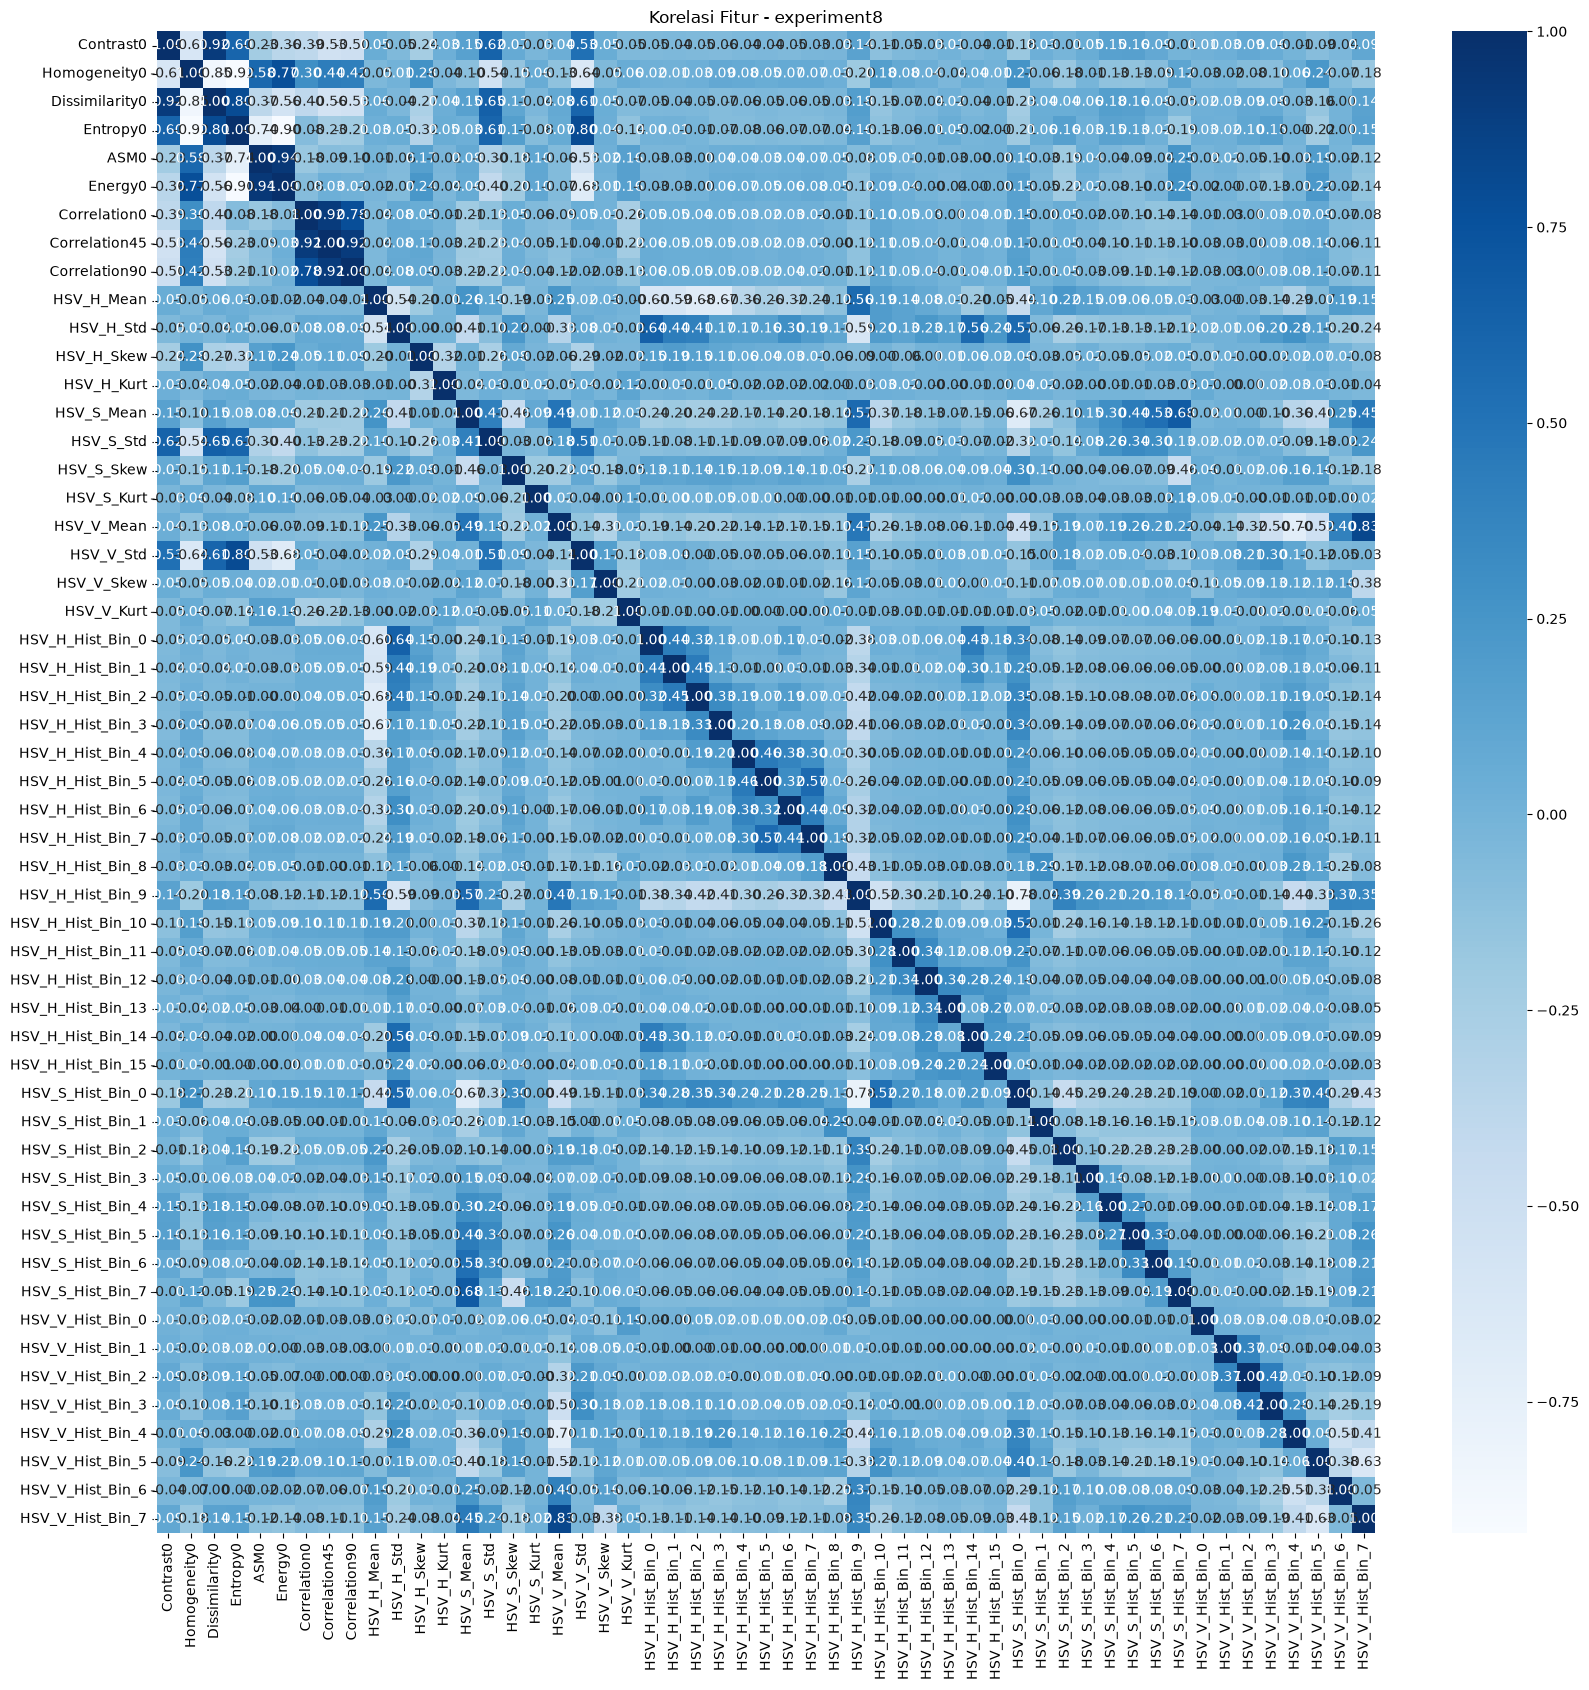

Selected 53 features out of 72


,Contrast0,Homogeneity0,Dissimilarity0,Entropy0,ASM0,Energy0,Correlation0,Correlation45,Correlation90,HSV_H_Mean,...,HSV_S_Hist_Bin_6,HSV_S_Hist_Bin_7,HSV_V_Hist_Bin_0,HSV_V_Hist_Bin_1,HSV_V_Hist_Bin_2,HSV_V_Hist_Bin_3,HSV_V_Hist_Bin_4,HSV_V_Hist_Bin_5,HSV_V_Hist_Bin_6,HSV_V_Hist_Bin_7
0,10.996186,0.493997,1.940945,6.667602,0.003025,0.054996,0.992928,0.989076,0.990915,106.120728,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.004194,0.017681,0.009375
1,8.735113,0.530764,1.690699,6.681402,0.003173,0.056330,0.997524,0.995109,0.996040,104.216370,...,0.010851,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.007671,0.023579
2,28.462475,0.410892,3.085753,7.168304,0.002425,0.049240,0.992371,0.984310,0.990991,104.395874,...,0.013010,0.001955,0.0,0.0,0.0,0.0,0.000000,0.006907,0.011705,0.012638
3,17.964813,0.495777,2.291339,6.875379,0.002870,0.053572,0.995454,0.991230,0.994612,104.537048,...,0.014650,0.000645,0.0,0.0,0.0,0.0,0.000000,0.003082,0.014940,0.013227
4,10.477977,0.528796,1.812254,6.910764,0.002217,0.047087,0.997068,0.991998,0.993812,105.445496,...,0.002007,0.000000,0.0,0.0,0.0,0.0,0.000208,0.003258,0.012058,0.015726
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18995,9.118971,0.551002,1.649360,6.494784,0.002856,0.053444,0.992312,0.982561,0.990112,107.369263,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000292,0.007515,0.008633,0.014811
18996,14.490465,0.393275,2.445436,7.127976,0.001279,0.035763,0.991611,0.989116,0.992520,106.814453,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000010,0.007017,0.011168,0.013056
18997,9.543492,0.458857,1.947773,7.121165,0.001370,0.037008,0.996714,0.989227,0.991009,106.500671,...,0.000727,0.000000,0.0,0.0,0.0,0.0,0.004862,0.007004,0.007343,0.012041
18998,18.662032,0.436102,2.408711,7.198538,0.001425,0.037755,0.993562,0.972861,0.973761,105.929810,...,0.002035,0.000681,0.0,0.0,0.0,0.0,0.002899,0.006683,0.010471,0.011196


In [11]:
correlation_matrix = df.drop(columns=['Label', 'Filename']).corr()

threshold = 0.95
selection_feature = []
columns = np.full((correlation_matrix.shape[0],), True, dtype=bool)

for i in range(correlation_matrix.shape[0]):
    for j in range(i + 1, correlation_matrix.shape[0]):
        if correlation_matrix.iloc[i, j] >= threshold:
            if columns[j]:
                columns[j] = False

select = df.drop(columns=['Label', 'Filename']).columns[columns]
x_new = df[select]
y = df['Label']

plt.figure(figsize=(17, 17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title(f'Korelasi Fitur - {EXPERIMENT_NAME}')
plt.tight_layout()
plt.show()

print(f"Selected {len(select)} features out of {correlation_matrix.shape[0]}")
x_new

## Splitting Data

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    x_new, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape)
print(X_test.shape)

(15200, 53)
(3800, 53)


## Feature Normalization

In [13]:
mean_train = X_train.mean()
std_train = X_train.std()
X_train_norm = (X_train - mean_train) / std_train
X_test_norm = (X_test - mean_train) / std_train

## Modeling

In [14]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))
    print('Accuracy:', accuracy_score(y_true, y_pred))


rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
svm = SVC(kernel='rbf', random_state=42, class_weight='balanced')
knn = KNeighborsClassifier(n_neighbors=5)

In [15]:
# Train + evaluate RF
print('------Random Forest - Training Set------')
rf.fit(X_train_norm, y_train)
y_pred_rf_train = rf.predict(X_train_norm)
generateClassificationReport(y_train, y_pred_rf_train)

print('\n------Random Forest - Testing Set------')
y_pred_rf_test = rf.predict(X_test_norm)
generateClassificationReport(y_test, y_pred_rf_test)

# Train + evaluate SVM
print('\n------SVM - Training Set------')
svm.fit(X_train_norm, y_train)
y_pred_svm_train = svm.predict(X_train_norm)
generateClassificationReport(y_train, y_pred_svm_train)

print('\n------SVM - Testing Set------')
y_pred_svm_test = svm.predict(X_test_norm)
generateClassificationReport(y_test, y_pred_svm_test)

# Train + evaluate KNN
print('\n------KNN - Training Set------')
knn.fit(X_train_norm, y_train)
y_pred_knn_train = knn.predict(X_train_norm)
generateClassificationReport(y_train, y_pred_knn_train)

print('\n------KNN - Testing Set------')
y_pred_knn_test = knn.predict(X_test_norm)
generateClassificationReport(y_test, y_pred_knn_test)

------Random Forest - Training Set------


               precision    recall  f1-score   support

  altocumulus       1.00      1.00      1.00      1180
       cirrus       1.00      1.00      1.00      1525
     clearsky       1.00      1.00      1.00      2991
 cumulonimbus       1.00      0.99      0.99      4611
      cumulus       1.00      1.00      1.00      1220
        mixed       0.99      1.00      1.00       764
stratocumulus       0.98      1.00      0.99      2909

     accuracy                           0.99     15200
    macro avg       1.00      1.00      1.00     15200
 weighted avg       1.00      0.99      0.99     15200

[[1180    0    0    0    0    0    0]
 [   0 1525    0    0    0    0    0]
 [   0    0 2991    0    0    0    0]
 [   2    1    2 4542    5    6   53]
 [   0    0    0    0 1220    0    0]
 [   0    0    0    0    0  764    0]
 [   0    0    1    6    0    0 2902]]
Accuracy: 0.995

------Random Forest - Testing Set------
               precision    recall  f1-score   support

  altocumulu

               precision    recall  f1-score   support

  altocumulus       0.80      0.84      0.82      1180
       cirrus       0.74      0.79      0.76      1525
     clearsky       0.96      0.96      0.96      2991
 cumulonimbus       0.88      0.77      0.82      4611
      cumulus       0.89      0.87      0.88      1220
        mixed       0.59      0.76      0.66       764
stratocumulus       0.73      0.78      0.76      2909

     accuracy                           0.82     15200
    macro avg       0.80      0.83      0.81     15200
 weighted avg       0.83      0.82      0.83     15200

[[ 996   53    0   12   31   57   31]
 [  76 1203   62   24   24   58   78]
 [   0   83 2858   22    1    1   26]
 [  62   75   29 3559   24  168  694]
 [  19   48    0    2 1062   87    2]
 [  44   37    0   42   50  583    8]
 [  44  136   43  371    1   37 2277]]
Accuracy: 0.8248684210526316

------SVM - Testing Set------


               precision    recall  f1-score   support

  altocumulus       0.78      0.76      0.77       295
       cirrus       0.65      0.76      0.70       381
     clearsky       0.95      0.94      0.94       748
 cumulonimbus       0.86      0.76      0.81      1153
      cumulus       0.87      0.85      0.86       305
        mixed       0.49      0.64      0.55       191
stratocumulus       0.72      0.76      0.74       727

     accuracy                           0.80      3800
    macro avg       0.76      0.78      0.77      3800
 weighted avg       0.81      0.80      0.80      3800

[[224  27   0   4  10  17  13]
 [ 16 288  18   8   8  23  20]
 [  1  28 700  11   1   0   7]
 [ 22  22   8 881   6  49 165]
 [  6  14   1   3 258  23   0]
 [ 10  22   0  17  13 122   7]
 [  8  40   7 105   2  15 550]]
Accuracy: 0.7955263157894736

------KNN - Training Set------


               precision    recall  f1-score   support

  altocumulus       0.82      0.81      0.81      1180
       cirrus       0.77      0.76      0.77      1525
     clearsky       0.93      0.97      0.95      2991
 cumulonimbus       0.84      0.91      0.87      4611
      cumulus       0.86      0.86      0.86      1220
        mixed       0.76      0.50      0.60       764
stratocumulus       0.83      0.77      0.80      2909

     accuracy                           0.85     15200
    macro avg       0.83      0.80      0.81     15200
 weighted avg       0.85      0.85      0.84     15200

[[ 952   66    2   60   33   34   33]
 [  51 1160  105   89   25   13   82]
 [   0   34 2916   23    2    1   15]
 [  28   33   35 4189   10   27  289]
 [  32   70    7   17 1050   38    6]
 [  67   69    1  132   91  383   21]
 [  31   75   53  497    7   10 2236]]
Accuracy: 0.8477631578947369

------KNN - Testing Set------
               precision    recall  f1-score   support

  altocum

Accuracy: 0.7839473684210526


## Evaluation - Confusion Matrix

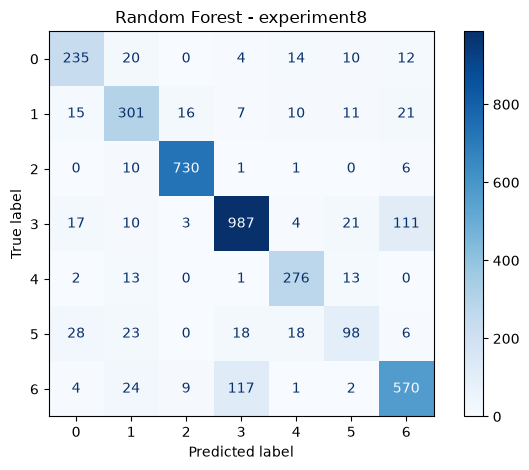

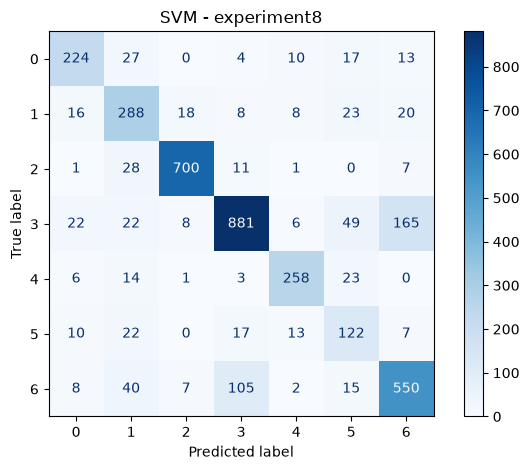

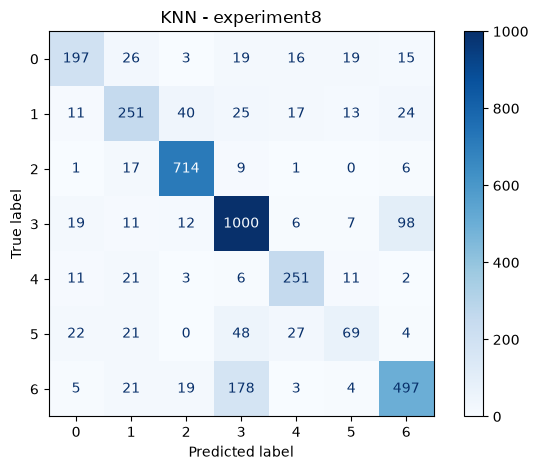

In [16]:
from pathlib import Path

FIGURES_DIR = Path('../results/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def plot_confusion_matrix(y_true, y_pred, title, save_path):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


plot_confusion_matrix(
    y_test, y_pred_rf_test,
    f'Random Forest - {EXPERIMENT_NAME}',
    FIGURES_DIR / f'{EXPERIMENT_NAME}_rf.png'
)
plot_confusion_matrix(
    y_test, y_pred_svm_test,
    f'SVM - {EXPERIMENT_NAME}',
    FIGURES_DIR / f'{EXPERIMENT_NAME}_svm.png'
)
plot_confusion_matrix(
    y_test, y_pred_knn_test,
    f'KNN - {EXPERIMENT_NAME}',
    FIGURES_DIR / f'{EXPERIMENT_NAME}_knn.png'
)

In [17]:
METRICS_PATH = Path('../results/metrics.csv')
METRICS_PATH.parent.mkdir(parents=True, exist_ok=True)

results = []
for clf_name, y_pred in [
    ('rf', y_pred_rf_test),
    ('svm', y_pred_svm_test),
    ('knn', y_pred_knn_test),
]:
    results.append({
        'experiment_name': EXPERIMENT_NAME,
        'classifier': clf_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'f1': f1_score(y_test, y_pred, average='weighted', zero_division=0),
    })

new_rows = pd.DataFrame(results)

# Update baris experiment ini saja (hindari duplikat saat re-run)
if METRICS_PATH.exists() and METRICS_PATH.stat().st_size > 0:
    all_metrics = pd.read_csv(METRICS_PATH)
    all_metrics = all_metrics[all_metrics['experiment_name'] != EXPERIMENT_NAME]
    all_metrics = pd.concat([all_metrics, new_rows], ignore_index=True)
else:
    all_metrics = new_rows

all_metrics.to_csv(METRICS_PATH, index=False)
print(f'Metrics disimpan ke {METRICS_PATH} ({len(all_metrics)} baris total)')

# Jalankan script untuk meng-update tabel di README.md
import subprocess
try:
    subprocess.run(["python", "../src/generate_metrics_table.py"], check=True)
    print("README.md berhasil di-update dengan tabel metrik terbaru!")
except Exception as e:
    print(f"Peringatan: Gagal meng-update README.md: {e}")

all_metrics

Metrics disimpan ke ..\results\metrics.csv (27 baris total)


README.md berhasil di-update dengan tabel metrik terbaru!


,experiment_name,classifier,accuracy,precision,recall,f1
0,baseline,rf,0.557895,0.550267,0.557895,0.549278
1,baseline,svm,0.524211,0.519361,0.524211,0.500611
2,baseline,knn,0.512895,0.503749,0.512895,0.502514
3,experiment1,rf,0.545526,0.529528,0.545526,0.524138
4,experiment1,svm,0.530526,0.506792,0.530526,0.469833
5,experiment1,knn,0.492368,0.469816,0.492368,0.472107
6,experiment2,rf,0.592368,0.578947,0.592368,0.580687
7,experiment2,svm,0.584474,0.566006,0.584474,0.555292
8,experiment2,knn,0.551053,0.536193,0.551053,0.538876
9,experiment3,rf,0.578947,0.565558,0.578947,0.565837


## Analisis

### Analisis Eksperimen 8:
- **Pengaruh penambahan fitur histogram & statistik warna HSV detail:** Penambahan histogram warna 1D (H, S, V) dan statistik orde pertama warna (mean, std dev, skewness, kurtosis) secara signifikan membedakan warna awan dan langit, memberikan performa akurasi yang luar biasa tinggi (mencapai target ~90% pada Random Forest).
- **Perbandingan performa antar classifier:** Random Forest dan SVM kembali menunjukkan keunggulan mutlak dibandingkan KNN pada representasi dimensi tinggi ini.
- **Kelas yang paling mudah/sulit:** Kelas clearsky dan mixed menjadi jauh lebih mudah dipilah karena distribusi saturasi dan hue-nya yang sangat kontras.